# NuGraph ES/CC Training Visualization

This notebook reads existing NuGraph outputs only. It does not modify repository code.

It covers:

1. processed graph file checks  
2. train/validation/test label balance  
3. one-graph TPC/PDS content check  
4. graph-size distributions  
5. TensorBoard scalar curves  
6. checkpoint discovery  
7. optional `test.py` command  
8. confusion matrix normalized in decimals  


In [1]:
# Configuration

import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from pynuml.data import NuGraphData

SCRIPT_DIR = Path("/home/apaudel/NuGraph/scripts")
DATA_FILE = SCRIPT_DIR / "merged1_July3"

LOG_ROOT = Path(os.environ.get("NUGRAPH_LOG", "/home/apaudel/NuGraph/logs"))

# Change this for the TPC+PDS run later, e.g. "merged1_July3_tpc_pds"
RUN_NAME = "merged1_July3_tpc_pds"
RUN_DIR = LOG_ROOT / RUN_NAME

#PRED_FILE = SCRIPT_DIR / f"{RUN_NAME}_predictions.h5"
#PRED_FILE = Path("/home/apaudel/NuGraph/scripts/merged1_July3_tpc_event_predictions.h5")
PRED_FILE = Path("/home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_event_predictions.h5")
print("DATA_FILE:", DATA_FILE)
print("LOG_ROOT :", LOG_ROOT)
print("RUN_DIR  :", RUN_DIR)
print("PRED_FILE:", PRED_FILE)


DATA_FILE: /home/apaudel/NuGraph/scripts/merged1_July3
LOG_ROOT : /home/apaudel/NuGraph/logs
RUN_DIR  : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds
PRED_FILE: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_event_predictions.h5


## 1. Graph file structure check

In [2]:
assert DATA_FILE.exists(), f"Missing file: {DATA_FILE}"

with h5py.File(DATA_FILE, "r") as f:
    print("Top-level groups:")
    for k in f.keys():
        print(" ", k)

    required = [
        "dataset",
        "samples/train",
        "samples/validation",
        "samples/test",
        "datasize/train",
        "event_classes",
        "semantic_classes",
        "planes",
    ]

    print("\nRequired checks:")
    missing = []
    for k in required:
        ok = k in f
        print(f"{k:25s}", "FOUND" if ok else "MISSING")
        if not ok:
            missing.append(k)

    if missing:
        raise RuntimeError(f"Missing required entries: {missing}")

    event_classes = f["event_classes"].asstr()[()].tolist()
    semantic_classes = f["semantic_classes"].asstr()[()].tolist()
    planes = f["planes"].asstr()[()].tolist()

print("\nevent_classes:", event_classes)
print("semantic_classes:", semantic_classes)
print("planes:", planes)


Top-level groups:
  dataset
  datasize
  event_classes
  gen
  planes
  samples
  semantic_classes

Required checks:
dataset                   FOUND
samples/train             FOUND
samples/validation        FOUND
samples/test              FOUND
datasize/train            FOUND
event_classes             FOUND
semantic_classes          FOUND
planes                    FOUND

event_classes: ['cc_nue', 'es_nue']
semantic_classes: ['pion', 'muon', 'kaon', 'hadron', 'shower', 'lowE_electron', 'michel', 'diffuse']
planes: ['u', 'v', 'y']


## 2. Label balance by split

This uses `NuGraphData.load()` because `dataset/<graph_key>` is a serialized graph dataset, not a normal HDF5 group.


In [3]:
def load_split_labels(data_file):
    rows = []
    with h5py.File(data_file, "r") as f:
        event_classes = f["event_classes"].asstr()[()].tolist()

        for split in ["train", "validation", "test"]:
            samples = f[f"samples/{split}"].asstr()[()]
            labels = []

            for key in samples:
                data = NuGraphData.load(f[f"dataset/{key}"])
                labels.append(int(data["evt"].y.item()))

            counts = Counter(labels)
            total = len(labels)
            row = {"split": split, "total": total}

            for i, cls in enumerate(event_classes):
                row[cls] = counts.get(i, 0)
                row[f"{cls}_fraction"] = counts.get(i, 0) / total if total else np.nan

            rows.append(row)

    return pd.DataFrame(rows), event_classes

balance_df, event_classes = load_split_labels(DATA_FILE)
balance_df


,split,total,cc_nue,cc_nue_fraction,es_nue,es_nue_fraction
0,train,15036,8834,0.587523,6202,0.412477
1,validation,835,500,0.598802,335,0.401198
2,test,835,488,0.584431,347,0.415569


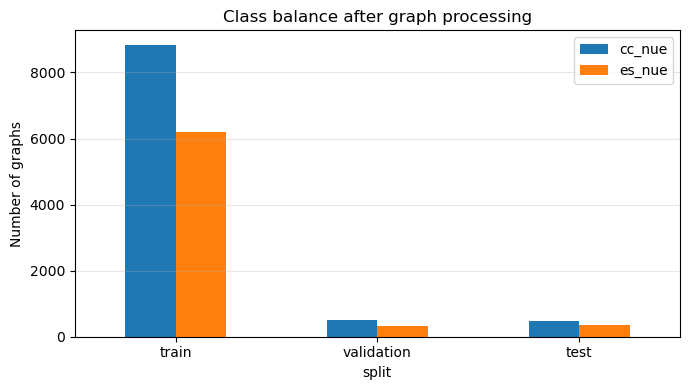

,split,total,cc_nue,es_nue,cc_nue_fraction,es_nue_fraction
0,train,15036,8834,6202,0.587523,0.412477
1,validation,835,500,335,0.598802,0.401198
2,test,835,488,347,0.584431,0.415569


In [4]:
count_cols = event_classes
ax = balance_df.set_index("split")[count_cols].plot(kind="bar", figsize=(7, 4))
ax.set_ylabel("Number of graphs")
ax.set_title("Class balance after graph processing")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

frac_cols = [f"{c}_fraction" for c in event_classes]
display(balance_df[["split", "total"] + count_cols + frac_cols])


## 3. Inspect one graph

In [5]:
with h5py.File(DATA_FILE, "r") as f:
    key = f["samples/train"].asstr()[()][0]
    data = NuGraphData.load(f[f"dataset/{key}"])

print("sample:", key)
print("node types:", data.node_types)
print("edge types:", data.edge_types)
print("event label:", data["evt"].y, "=>", event_classes[int(data["evt"].y.item())])

for node in ["hit", "sp", "evt", "ophit", "pmt", "flash"]:
    if node in data.node_types:
        print("")
        print(node)
        if hasattr(data[node], "x"):
            print("  x:", tuple(data[node].x.shape))
        if hasattr(data[node], "pos"):
            print("  pos:", tuple(data[node].pos.shape))
        if hasattr(data[node], "y"):
            print("  y:", data[node].y.tolist())


sample: r20000048_sr48_evt2380
node types: ['metadata', 'sp', 'hit', 'evt', 'particle-truth', 'ophit', 'flash', 'pmt']
edge types: [('hit', 'delaunay', 'hit'), ('hit', 'delaunay-planar', 'hit'), ('hit', 'nexus', 'sp'), ('hit', 'in', 'evt'), ('sp', 'in', 'evt'), ('hit', 'cluster-truth', 'particle-truth'), ('ophit', 'in', 'pmt'), ('pmt', 'in', 'flash'), ('flash', 'in', 'evt'), ('sp', 'knn', 'pmt')]
event label: tensor([0]) => cc_nue

hit
  x: (31, 6)
  pos: (31, 2)

sp
  x: (10, 0)
  pos: (10, 3)

evt
  x: (1, 0)
  y: [0]

ophit
  x: (277, 9)
  pos: (277, 3)

pmt
  x: (70, 4)
  pos: (70, 2)

flash
  x: (1, 10)
  pos: (1, 3)


## 4. Graph-size distributions

In [6]:
MAX_GRAPHS_PER_SPLIT = 500  # increase if needed

rows = []
with h5py.File(DATA_FILE, "r") as f:
    for split in ["train", "validation", "test"]:
        samples = f[f"samples/{split}"].asstr()[()]
        for key in samples[:MAX_GRAPHS_PER_SPLIT]:
            data = NuGraphData.load(f[f"dataset/{key}"])
            label = int(data["evt"].y.item())
            row = {
                "split": split,
                "key": key,
                "label": label,
                "class": event_classes[label],
            }
            for node in ["hit", "sp", "ophit", "pmt", "flash"]:
                row[f"n_{node}"] = int(data[node].num_nodes) if node in data.node_types else 0
            rows.append(row)

graph_stats = pd.DataFrame(rows)
graph_stats.head()


,split,key,label,class,n_hit,n_sp,n_ophit,n_pmt,n_flash
0,train,r20000048_sr48_evt2380,0,cc_nue,31,10,277,70,1
1,train,r20000120_sr120_evt5957,0,cc_nue,109,51,553,152,4
2,train,r20000042_sr42_evt2079,0,cc_nue,34,10,352,107,1
3,train,r20000013_sr13_evt10640,1,es_nue,11,7,189,75,1
4,train,r20000010_sr10_evt10492,1,es_nue,14,5,137,46,1


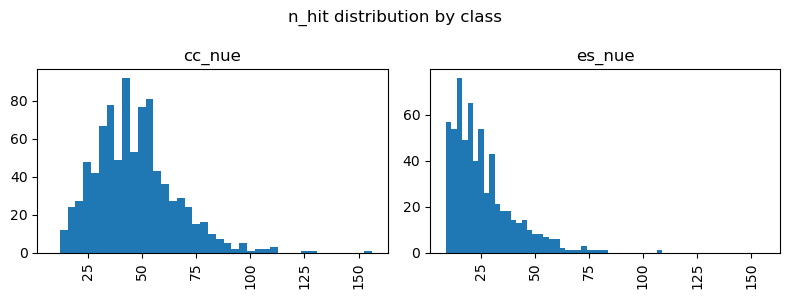

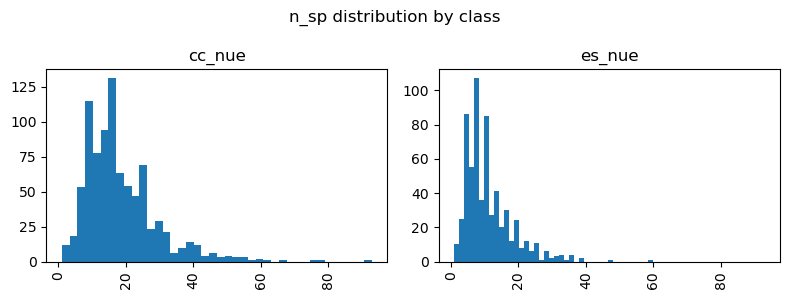

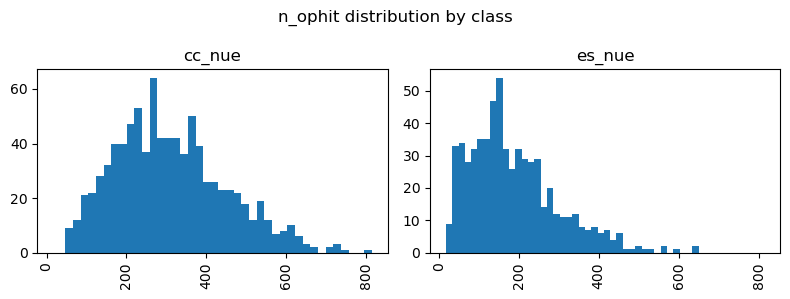

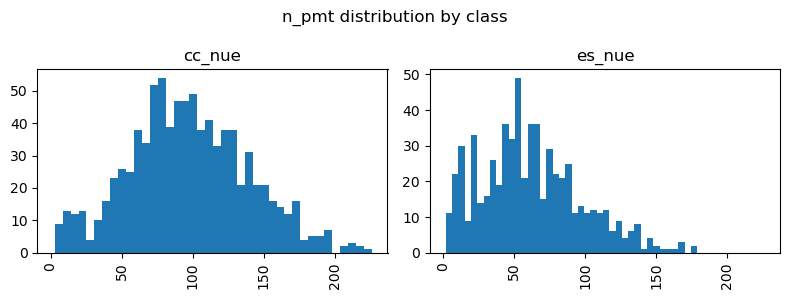

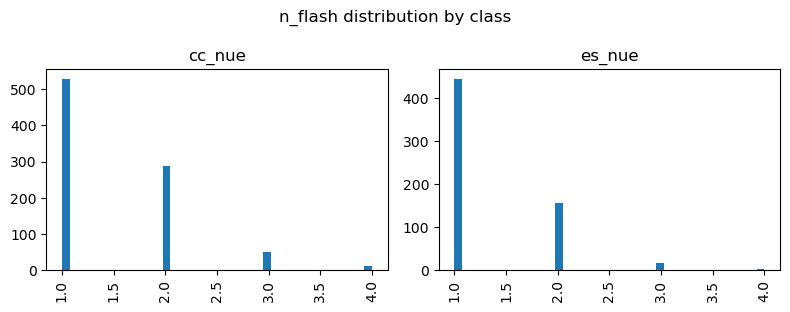

n_hit                                                 \
                   count       mean        std   min   25%   50%    75%   
split      class                                                          
test       cc_nue  297.0  47.289562  18.725353  12.0  35.0  45.0  57.00   
           es_nue  203.0  25.561576  14.412931   9.0  15.0  21.0  30.00   
train      cc_nue  284.0  47.500000  18.488178  12.0  35.0  45.0  57.25   
           es_nue  216.0  24.902778  12.514728   9.0  15.0  22.0  30.00   
validation cc_nue  299.0  44.916388  18.447905  12.0  31.0  44.0  55.00   
           es_nue  201.0  26.597015  15.191175   9.0  16.0  22.0  33.00   

                           n_sp             ...   n_pmt        n_flash  \
                     max  count       mean  ...     75%    max   count   
split      class                            ...                          
test       cc_nue  130.0  297.0  18.306397  ...  123.00  226.0   297.0   
           es_nue   79.0  203.0  10.743842  ...   81.00  165.0   203.0   
train      cc_nue  110.0  284.0  19.137324  ...  124.25  215.0   284.0   
           es_nue   72.0  216.0  11.027778  ...   79.00  167.0   216.0   
validation cc_nue  156.0  299.0  18.013378  ...  128.50  215.0   299.0   
           es_nue  109.0  201.0  11.507463  ...   88.00  179.0   201.0   

                                                                
                       mean       std  min  25%  50%  75%  max  
split      class                                                
test       cc_nue  1.454545  0.656661  1.0  1.0  1.0  2.0  4.0  
           es_nue  1.285714  0.560360  1.0  1.0  1.0  1.0  4.0  
train      cc_nue  1.436620  0.656199  1.0  1.0  1.0  2.0  4.0  
           es_nue  1.314815  0.522038  1.0  1.0  1.0  2.0  3.0  
validation cc_nue  1.551839  0.675423  1.0  1.0  1.0  2.0  4.0  
           es_nue  1.358209  0.566608  1.0  1.0  1.0  2.0  4.0  

[6 rows x 40 columns]

In [7]:
for col in ["n_hit", "n_sp", "n_ophit", "n_pmt", "n_flash"]:
    if col not in graph_stats.columns:
        continue

    graph_stats.hist(column=col, by="class", bins=40, figsize=(8, 3), sharex=True)
    plt.suptitle(f"{col} distribution by class")
    plt.tight_layout()
    plt.show()

summary = graph_stats.groupby(["split", "class"])[["n_hit", "n_sp", "n_ophit", "n_pmt", "n_flash"]].describe()
display(summary)


## 5. TensorBoard scalar curves

In [8]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tensorboard_scalars(run_dir):
    run_dir = Path(run_dir)
    event_files = sorted(run_dir.rglob("events.out.tfevents*"))

    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event files found under {run_dir}")

    rows = []
    for event_file in event_files:
        ea = EventAccumulator(str(event_file))
        ea.Reload()

        for tag in ea.Tags().get("scalars", []):
            for ev in ea.Scalars(tag):
                rows.append({
                    "event_file": str(event_file),
                    "tag": tag,
                    "step": ev.step,
                    "wall_time": ev.wall_time,
                    "value": ev.value,
                })

    return pd.DataFrame(rows)

scalars = load_tensorboard_scalars(RUN_DIR)
print("Loaded scalar rows:", len(scalars))
print("Tags:")
for tag in sorted(scalars["tag"].unique()):
    print(" ", tag)

scalars.head()


Loaded scalar rows: 5357
Tags:
  epoch
  event/loss-train
  event/loss-val
  event/precision-train
  event/precision-val
  event/recall-train
  event/recall-val
  loss/train
  loss/val
  lr-AdamW
  temperature/event


,event_file,tag,step,wall_time,value
0,/home/apaudel/NuGraph/logs/merged1_July3_tpc_p...,lr-AdamW,49,1.783274e+09,0.000040
1,/home/apaudel/NuGraph/logs/merged1_July3_tpc_p...,lr-AdamW,99,1.783274e+09,0.000040
2,/home/apaudel/NuGraph/logs/merged1_July3_tpc_p...,lr-AdamW,149,1.783274e+09,0.000040
3,/home/apaudel/NuGraph/logs/merged1_July3_tpc_p...,lr-AdamW,199,1.783274e+09,0.000041
4,/home/apaudel/NuGraph/logs/merged1_July3_tpc_p...,lr-AdamW,249,1.783274e+09,0.000041


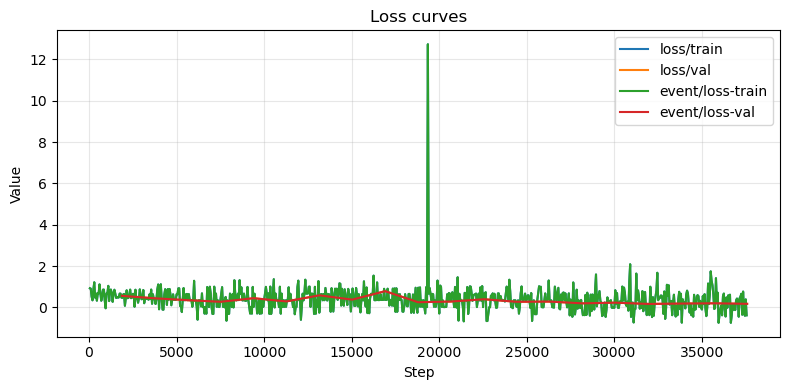

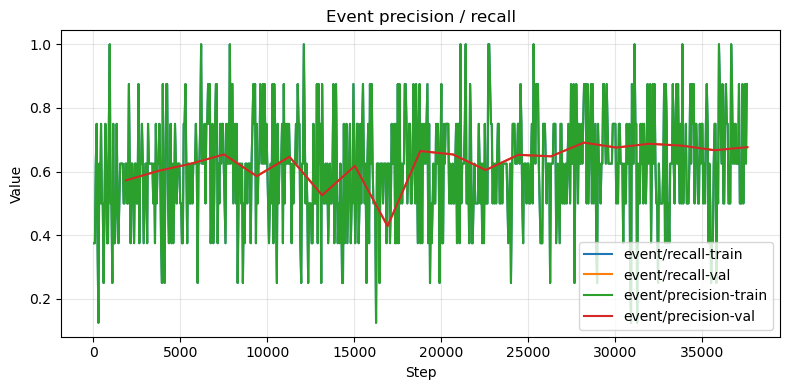

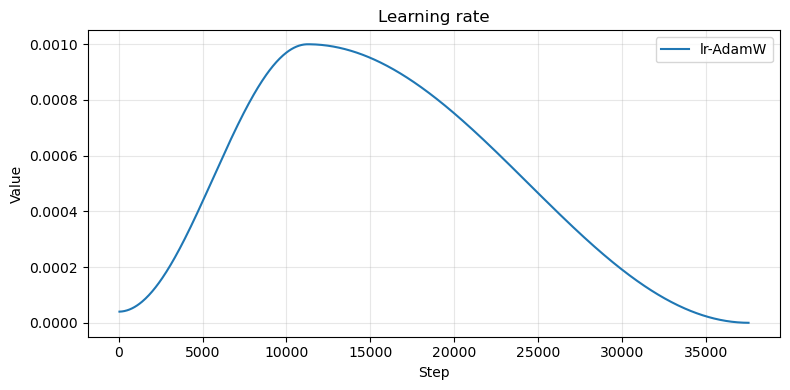

In [9]:
def plot_tags(df, tags, title):
    present = [t for t in tags if t in set(df["tag"])]
    if not present:
        print("No requested tags found:", tags)
        return

    fig, ax = plt.subplots(figsize=(8, 4))
    for tag in present:
        d = df[df["tag"] == tag].sort_values("step")
        ax.plot(d["step"], d["value"], label=tag)

    ax.set_xlabel("Step")
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_tags(scalars, ["loss/train", "loss/val", "event/loss-train", "event/loss-val"], "Loss curves")
plot_tags(scalars, ["event/recall-train", "event/recall-val", "event/precision-train", "event/precision-val"], "Event precision / recall")
plot_tags(scalars, ["lr-AdamW"], "Learning rate")


In [10]:
latest_rows = []
for tag, d in scalars.groupby("tag"):
    d = d.sort_values("step")
    last = d.iloc[-1]
    latest_rows.append({"tag": tag, "step": int(last["step"]), "value": float(last["value"])})

latest_df = pd.DataFrame(latest_rows).sort_values("tag")
latest_df


,tag,step,value
0,epoch,37579,1.900000e+01
1,event/loss-train,37549,-3.780430e-01
2,event/loss-val,37579,1.760899e-01
3,event/precision-train,37549,8.750000e-01
4,event/precision-val,37579,6.766467e-01
5,event/recall-train,37549,8.750000e-01
6,event/recall-val,37579,6.766467e-01
7,loss/train,37549,-3.780430e-01
8,loss/val,37579,1.760899e-01
9,lr-AdamW,37549,7.209005e-09


## 6. Find checkpoint

In [12]:
ckpts = sorted(RUN_DIR.rglob("*.ckpt"), key=lambda p: p.stat().st_mtime)

print("Checkpoints:")
for p in ckpts:
    print(" ", p)

CKPT = ckpts[-1] if ckpts else None
print("\nSelected checkpoint:", CKPT)


Checkpoints:
  /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds/version_0/checkpoints/epoch=19-step=37580.ckpt

Selected checkpoint: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds/version_0/checkpoints/epoch=19-step=37580.ckpt


## 7. Optional inference command

Set `RUN_TEST = True` only after checking the printed command.

- For TPC-only: `USE_OPTICAL = False`
- For TPC+PDS: `USE_OPTICAL = True`


In [13]:
import subprocess
import shlex

RUN_TEST = False
USE_OPTICAL = True

if CKPT is None:
    print("No checkpoint found. Cannot run test.py yet.")
else:
    cmd = [
        "python", "test.py",
        "--device", "0",
        "--data-path", str(DATA_FILE),
        "--checkpoint", str(CKPT),
        "--outfile", str(PRED_FILE),
        "--batch-size", "8",
        "--num-workers", "0",
    ]

    if USE_OPTICAL:
        cmd.append("--optical")

    print("Command:")
    print(" ".join(shlex.quote(x) for x in cmd))

    if RUN_TEST:
        result = subprocess.run(cmd, cwd=str(SCRIPT_DIR), text=True)
        print("Return code:", result.returncode)


Command:
python test.py --device 0 --data-path /home/apaudel/NuGraph/scripts/merged1_July3 --checkpoint /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds/version_0/checkpoints/epoch=19-step=37580.ckpt --outfile /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_event_predictions.h5 --batch-size 8 --num-workers 0 --optical


## 8. Inspect prediction file

In [14]:
def print_h5_tree(fname, max_lines=200):
    fname = Path(fname)
    if not fname.exists():
        print("Prediction file does not exist yet:", fname)
        return

    n = 0
    with h5py.File(fname, "r") as f:
        def visitor(name, obj):
            nonlocal n
            if n >= max_lines:
                return
            if isinstance(obj, h5py.Dataset):
                print(name, obj.shape, obj.dtype)
            else:
                print(name, "GROUP")
            n += 1

        f.visititems(visitor)

print_h5_tree(PRED_FILE)


events GROUP
events/_i_table GROUP
events/_i_table/index GROUP
events/_i_table/index/abounds (0,) int64
events/_i_table/index/bounds (0, 127) int64
events/_i_table/index/indices (0, 131072) uint32
events/_i_table/index/indicesLR (131072,) uint32
events/_i_table/index/mbounds (0,) int64
events/_i_table/index/mranges (0,) int64
events/_i_table/index/ranges (0, 2) int64
events/_i_table/index/sorted (0, 131072) int64
events/_i_table/index/sortedLR (131201,) int64
events/_i_table/index/zbounds (0,) int64
events/table (835,) [('index', '<i8'), ('values_block_0', '<i8', (5,)), ('values_block_1', '<f8', (2,))]


## 9. Load predictions flexibly

In [15]:
import numpy as np
import pandas as pd
from pathlib import Path

# Use the event-level prediction file, not the old hit-level file
PRED_FILE = Path("/home/apaudel/NuGraph/scripts/merged1_July3_tpc_event_predictions.h5")

def load_event_predictions(pred_file):
    pred_file = Path(pred_file)

    if not pred_file.exists():
        raise FileNotFoundError(f"Prediction file not found: {pred_file}")

    # Check what pandas HDF tables exist
    with pd.HDFStore(pred_file, "r") as store:
        keys = store.keys()

    print("HDF keys found:", keys)

    if "/events" not in keys:
        raise RuntimeError(
            "Could not find '/events' table. "
            "This is probably not the event-level prediction file."
        )

    # Read event-level prediction table
    df = pd.read_hdf(pred_file, "events")

    required_columns = ["y_true", "y_pred"]
    for col in required_columns:
        if col not in df.columns:
            raise RuntimeError(f"Missing required column: {col}")

    y_true = df["y_true"].to_numpy(dtype=int)
    y_pred = df["y_pred"].to_numpy(dtype=int)

    print("\nLoaded event predictions successfully")
    print("File:", pred_file)
    print("Number of events:", len(df))
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst few rows:")
    display(df.head())

    print("\nTrue label counts:")
    print(df["y_true"].value_counts().sort_index())

    print("\nPredicted label counts:")
    print(df["y_pred"].value_counts().sort_index())

    return y_true, y_pred, df

y_true, y_pred, df_pred = load_event_predictions(PRED_FILE)

HDF keys found: ['/events']

Loaded event predictions successfully
File: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_event_predictions.h5
Number of events: 835

Columns:
['run', 'subrun', 'event', 'y_true', 'y_pred', 'prob_cc_nue', 'prob_es_nue']

First few rows:


,run,subrun,event,y_true,y_pred,prob_cc_nue,prob_es_nue
0,20000172,172,8593,0,0,0.749612,0.250388
1,20000011,11,528,0,0,0.503276,0.496724
2,20000200,200,9999,0,0,0.744280,0.255720
3,20000176,176,8790,0,0,0.500877,0.499123
4,20000171,171,8536,0,0,0.717828,0.282172



True label counts:
y_true
0    488
1    347
Name: count, dtype: int64

Predicted label counts:
y_pred
0    486
1    349
Name: count, dtype: int64


## 10. Confusion matrix normalized in decimals

Rows are true labels. Columns are predicted labels. The normalized matrix is row-normalized, so each row sums to 1.0.


Standard normalized confusion matrix:
rows = true [CC, ES], columns = predicted [CC, ES]
         pred_CC  pred_ES
true_CC    0.719    0.281
true_ES    0.389    0.611

Plot matrix:
rows = true [CC, ES], columns = predicted [ES, CC]
         pred_ES  pred_CC
true_CC    0.281    0.719
true_ES    0.611    0.389

Accuracy: 0.6743
CC efficiency: 0.7193
ES efficiency: 0.611


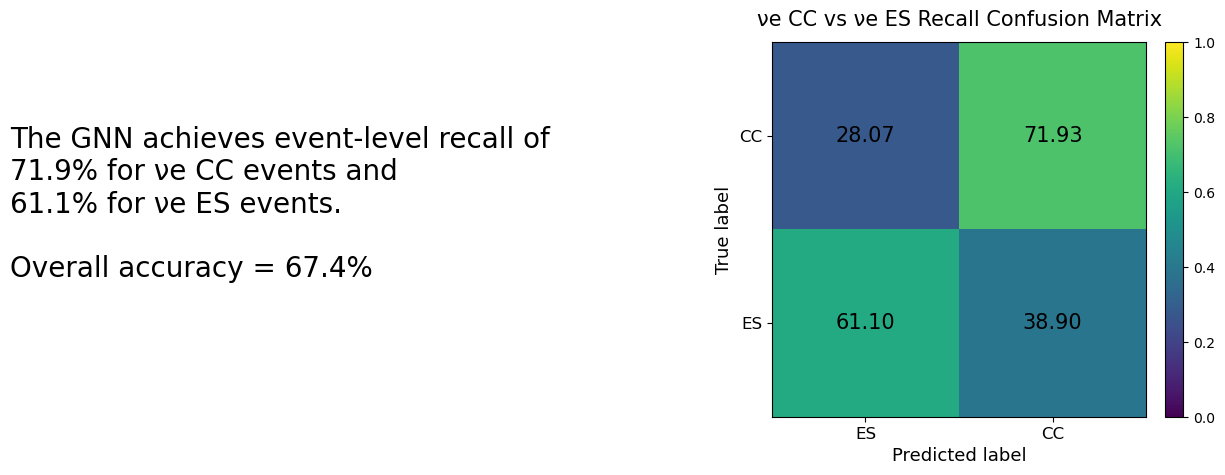

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, accuracy_score

# Event-level prediction file
PRED_FILE = Path("/home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_event_predictions.h5")

# Load predictions
df_pred = pd.read_hdf(PRED_FILE, "events")

y_true = df_pred["y_true"].to_numpy(dtype=int)
y_pred = df_pred["y_pred"].to_numpy(dtype=int)

# Label meaning:
# 0 = cc_nue
# 1 = es_nue

# Standard confusion matrix first:
# rows    = true [CC, ES]
# columns = pred [CC, ES]
cm_standard = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_standard_norm = cm_standard.astype(float) / cm_standard.sum(axis=1, keepdims=True)

# Reorder ONLY the x-axis to match your preferred plot style:
# rows    = true [CC, ES]
# columns = pred [ES, CC]
cm_plot = cm_standard[:, [1, 0]]
cm_plot_norm = cm_plot.astype(float) / cm_plot.sum(axis=1, keepdims=True)

accuracy = accuracy_score(y_true, y_pred)

cc_eff = cm_standard_norm[0, 0]  # true CC predicted CC
es_eff = cm_standard_norm[1, 1]  # true ES predicted ES

print("Standard normalized confusion matrix:")
print("rows = true [CC, ES], columns = predicted [CC, ES]")
print(pd.DataFrame(
    cm_standard_norm,
    index=["true_CC", "true_ES"],
    columns=["pred_CC", "pred_ES"]
).round(3))

print("\nPlot matrix:")
print("rows = true [CC, ES], columns = predicted [ES, CC]")
print(pd.DataFrame(
    cm_plot_norm,
    index=["true_CC", "true_ES"],
    columns=["pred_ES", "pred_CC"]
).round(3))

print("\nAccuracy:", round(accuracy, 4))
print("CC efficiency:", round(cc_eff, 4))
print("ES efficiency:", round(es_eff, 4))

# ------------------------------------------------------------
# Plot in the style of your reference screenshot
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 4.8))

# Left text panel
ax_text = fig.add_axes([0.04, 0.15, 0.43, 0.75])
ax_text.axis("off")

summary_text = (
    "The GNN achieves event-level recall of\n"
    f"{cc_eff*100:.1f}% for νe CC events and\n"
    f"{es_eff*100:.1f}% for νe ES events.\n\n"
    f"Overall accuracy = {accuracy*100:.1f}%"
)

ax_text.text(
    0.0,
    0.55,
    summary_text,
    fontsize=20,
    ha="left",
    va="center"
)

# Confusion matrix panel
ax = fig.add_axes([0.55, 0.12, 0.33, 0.78])

im = ax.imshow(cm_plot_norm, vmin=0, vmax=1, cmap="viridis")

ax.set_title("νe CC vs νe ES Recall Confusion Matrix", fontsize=15, pad=12)
ax.set_xlabel("Predicted label", fontsize=13)
ax.set_ylabel("True label", fontsize=13)

# Your desired ordering:
# y-axis: true CC, true ES
# x-axis: predicted ES, predicted CC
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["ES", "CC"], fontsize=12)
ax.set_yticklabels(["CC", "ES"], fontsize=12)

# Annotate cells as percentages, same style as your screenshot
for i in range(cm_plot_norm.shape[0]):
    for j in range(cm_plot_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{100*cm_plot_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=15,
            color="black"
        )

# Colorbar still uses 0 to 1 decimal scale
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

## 11. Efficiency and precision summary